# Week 2a — Manual Aperture Photometry from a TESS Target Pixel File

**Target:** CM Draconis (TIC 199574208) — a well-studied short-period eclipsing binary.

**Goal:** Understand how a SAP (Simple Aperture Photometry) light curve is built from raw pixel data, by doing it manually and comparing the result to the SPOC pipeline product.

**Steps:**
1. Download a Target Pixel File (TPF) and the matching SPOC light curve for one sector.
2. Inspect the TPF structure: flux cube, background, pipeline aperture mask, quality flags.
3. Perform aperture photometry by hand: background-subtract, apply mask, sum spatially.
4. Build a custom threshold-based aperture and compare it to the pipeline aperture.
5. Validate against the SPOC SAP_FLUX and Lightkurve's `to_lightcurve()` convenience method.

**Key takeaway:** SPOC SAP_FLUX = `sum((FLUX − FLUX_BKG) × aperture_mask)` + quality-flag filtering. Once you replicate those steps, the curves match.

In [1]:
%matplotlib inline

from lightkurve import search_targetpixelfile, search_lightcurve
import matplotlib.pyplot as plt
import numpy as np

/Users/csavva/Documents/Repositories/astro-research/.venv/lib/python3.12/site-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


---
## 1. Download the TPF and SPOC light curve

We search MAST for 2-minute cadence SPOC products and download the first available sector for both the TPF and the pre-built light curve.

In [2]:
TIC_ID = 'TIC 199574208'

# Search and display what's available
search_tpf = search_targetpixelfile(TIC_ID, author='SPOC', cadence=120)
search_lc  = search_lightcurve(TIC_ID, author='SPOC', cadence=120)
print(search_tpf)
print()
print(search_lc)

SearchResult containing 25 data products.

 #     mission     year author exptime target_name distance
                                  s                 arcsec 
--- -------------- ---- ------ ------- ----------- --------
  0 TESS Sector 16 2019   SPOC     120   199574208      0.0
  1 TESS Sector 19 2019   SPOC     120   199574208      0.0
  2 TESS Sector 22 2020   SPOC     120   199574208      0.0
  3 TESS Sector 23 2020   SPOC     120   199574208      0.0
  4 TESS Sector 24 2020   SPOC     120   199574208      0.0
  5 TESS Sector 25 2020   SPOC     120   199574208      0.0
  6 TESS Sector 26 2020   SPOC     120   199574208      0.0
  7 TESS Sector 59 2022   SPOC     120   199574208      0.0
  8 TESS Sector 58 2022   SPOC     120   199574208      0.0
  9 TESS Sector 56 2022   SPOC     120   199574208      0.0
 10 TESS Sector 57 2022   SPOC     120   199574208      0.0
 11 TESS Sector 51 2022   SPOC     120   199574208      0.0
 12 TESS Sector 50 2022   SPOC     120   199574208      0

In [3]:
# Download the first sector for both products
tpf = search_tpf[0].download()
lc  = search_lc[0].download()

print(f'TPF : {tpf.mission}  sector {tpf.sector}  shape {tpf.flux.shape}')
print(f'LC  : {lc.mission}   sector {lc.sector}   {len(lc)} cadences')

TPF : TESS  sector 16  shape (16708, 11, 11)
LC  : TESS   sector 16   16708 cadences


---
## 2. Inspect the TPF

A TPF is a 3D data cube: **(time × row × col)**. Each frame is a small postage-stamp image centred on the target. Key attributes:

- `tpf.flux` — the raw pixel flux cube (e⁻/s)
- `tpf.flux_bkg` — estimated sky background per pixel per cadence
- `tpf.pipeline_mask` — 2D boolean mask showing which pixels SPOC used for photometry
- `tpf.quality` — per-cadence quality flags (0 = good)
- `tpf.time` — timestamps in BTJD (Barycentric TESS Julian Date)

<Axes: title={'center': 'Target ID: 199574208, Cadence: 368062'}, xlabel='Pixel Column Number', ylabel='Pixel Row Number'>

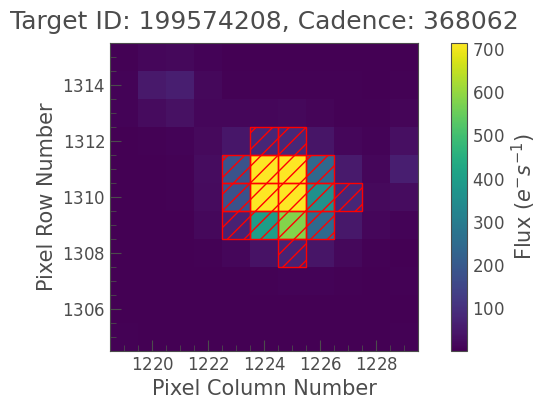

In [4]:
# Visualise a single frame with the pipeline aperture overlaid
tpf.plot(frame=0, aperture_mask=tpf.pipeline_mask)

In [5]:
# Unpack the arrays we'll work with
flux = tpf.flux.value             # 3D: (n_cadences, n_rows, n_cols)
bkg  = tpf.flux_bkg.value         # 3D: same shape — background estimate
time = tpf.time.value             # 1D: BTJD timestamps
pm   = tpf.pipeline_mask          # 2D: boolean aperture mask
qual = tpf.quality                # 1D: quality flags per cadence

print(f'Flux cube shape : {flux.shape}')
print(f'Pipeline mask   : {pm.sum()} pixels selected out of {pm.size}')
print(f'Good cadences   : {(qual == 0).sum()} / {len(qual)}')

Flux cube shape : (16708, 11, 11)
Pipeline mask   : 16 pixels selected out of 121
Good cadences   : 14900 / 16708


---
## 3. Manual aperture photometry (pipeline mask)

Simple aperture photometry is:

$$\text{SAP}(t) = \sum_{\text{pixel} \in \text{mask}} \big[\,\text{FLUX}(t, \text{pixel}) - \text{BKG}(t, \text{pixel})\,\big]$$

In NumPy, the mask broadcasts over the spatial axes and we sum over rows and columns (axes 1 and 2), keeping the time axis.

In [6]:
# Step 1: subtract background
# Step 2: multiply by aperture mask (zeros out pixels outside the aperture)
# Step 3: sum over spatial axes
sap_manual = np.nansum((flux - bkg) * pm, axis=(1, 2))

In [7]:
# Filter out bad cadences (scattered light, momentum dumps, etc.)
# The SPOC pipeline sets these to NaN in SAP_FLUX; we replicate that
# by masking on quality == 0.
good = qual == 0

time_good       = time[good]
sap_manual_good = sap_manual[good]

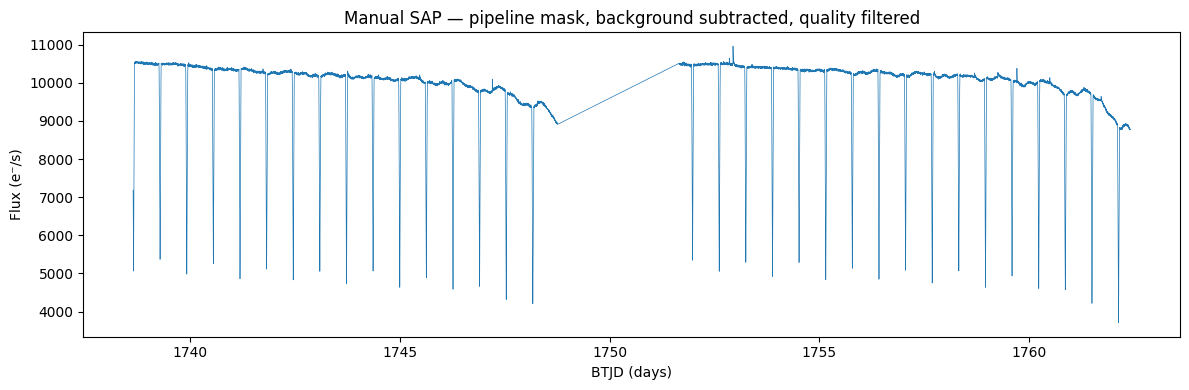

In [8]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(time_good, sap_manual_good, lw=0.5)
ax.set_xlabel('BTJD (days)')
ax.set_ylabel('Flux (e⁻/s)')
ax.set_title('Manual SAP — pipeline mask, background subtracted, quality filtered')
plt.tight_layout()

---
## 4. Custom threshold aperture

Instead of using the pipeline mask, we can build our own aperture by thresholding the median flux image. Pixels brighter than a chosen percentile are included.

Custom mask: 18 pixels  (pipeline uses 16)


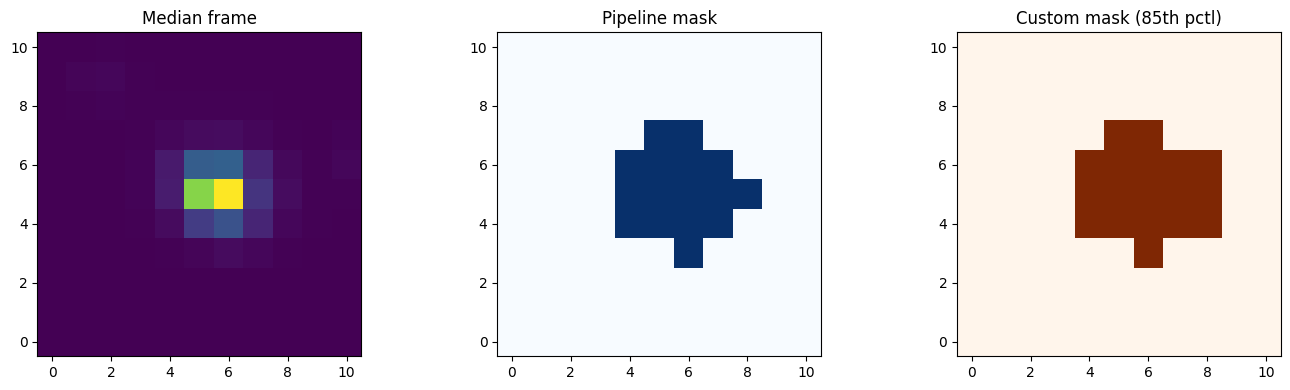

In [9]:
# Build a custom aperture from the median frame
median_frame = np.nanmedian(flux, axis=0)
threshold    = np.percentile(median_frame, 85)
custom_mask  = median_frame > threshold

print(f'Custom mask: {custom_mask.sum()} pixels  (pipeline uses {pm.sum()})')

# Show both masks side by side
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].imshow(median_frame, origin='lower')
axes[0].set_title('Median frame')
axes[1].imshow(pm.astype(int), origin='lower', cmap='Blues')
axes[1].set_title('Pipeline mask')
axes[2].imshow(custom_mask.astype(int), origin='lower', cmap='Oranges')
axes[2].set_title('Custom mask (85th pctl)')
plt.tight_layout()

In [10]:
# Aperture photometry with the custom mask
sap_custom = np.nansum((flux - bkg) * custom_mask, axis=(1, 2))
sap_custom_good = sap_custom[good]

---
## 5. Compare against SPOC SAP_FLUX

We now have three light curves to compare:
1. **Manual (pipeline mask)** — our hand-built version using the same aperture as SPOC.
2. **Manual (custom mask)** — our threshold-based aperture.
3. **SPOC SAP_FLUX** — the official pipeline product.

All are normalised by dividing by their median so they can be overplotted on the same scale.

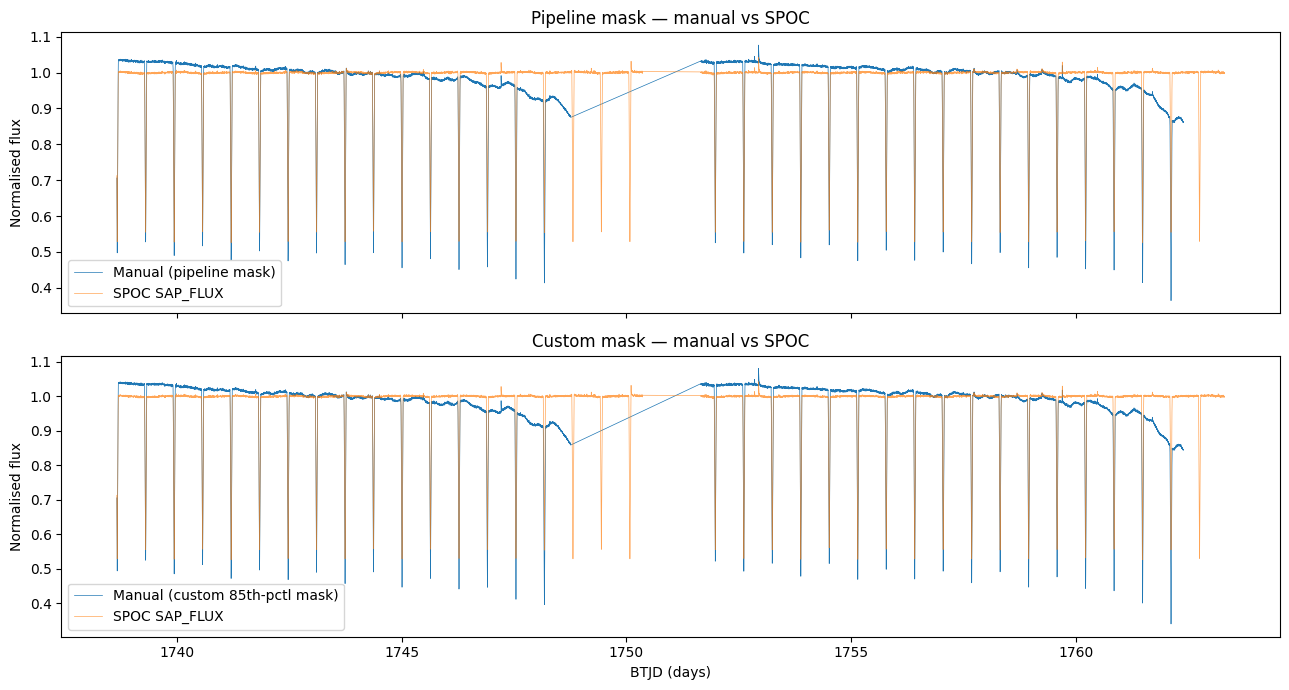

In [11]:
# Normalise each curve by its median
norm = lambda x: x / np.nanmedian(x)

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

# --- Top: manual (pipeline mask) vs SPOC SAP_FLUX ---
axes[0].plot(time_good, norm(sap_manual_good),
             lw=0.5, label='Manual (pipeline mask)')
axes[0].plot(lc.time.value, norm(lc.sap_flux.value),
             lw=0.5, alpha=0.7, label='SPOC SAP_FLUX')
axes[0].set_ylabel('Normalised flux')
axes[0].set_title('Pipeline mask — manual vs SPOC')
axes[0].legend()

# --- Bottom: custom mask vs SPOC SAP_FLUX ---
axes[1].plot(time_good, norm(sap_custom_good),
             lw=0.5, label='Manual (custom 85th-pctl mask)')
axes[1].plot(lc.time.value, norm(lc.sap_flux.value),
             lw=0.5, alpha=0.7, label='SPOC SAP_FLUX')
axes[1].set_ylabel('Normalised flux')
axes[1].set_xlabel('BTJD (days)')
axes[1].set_title('Custom mask — manual vs SPOC')
axes[1].legend()

plt.tight_layout()

---
## 6. Sanity check: Lightkurve's `to_lightcurve()`

As a final cross-check, Lightkurve can do the aperture sum for us via `tpf.to_lightcurve()`. This sums **raw** flux (no background subtraction) through the mask. We verify that our raw (no-bkg-sub) manual curve matches it exactly.

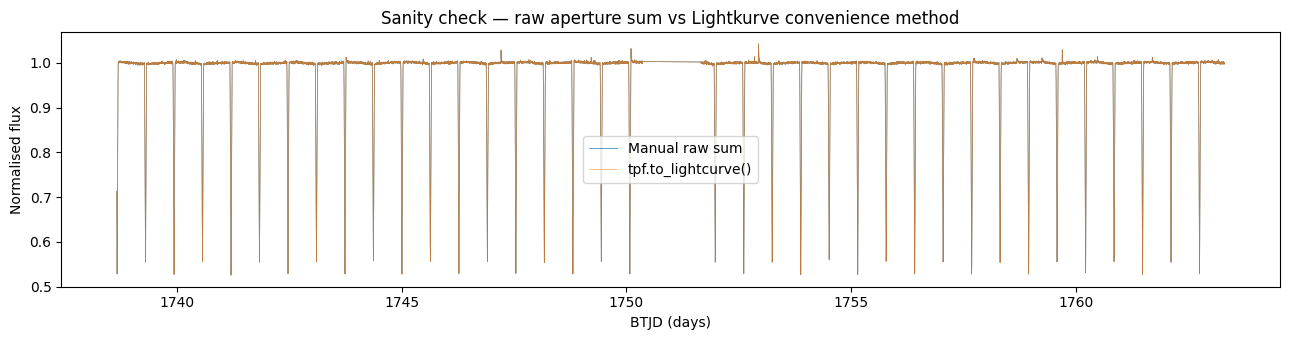

In [12]:
# Raw flux (no background subtraction) through the pipeline mask
sap_raw = np.nansum(flux * pm, axis=(1, 2))

# Lightkurve's convenience method
lc_from_tpf = tpf.to_lightcurve(aperture_mask='pipeline')

fig, ax = plt.subplots(figsize=(13, 3.5))
ax.plot(time, norm(sap_raw),
        lw=0.5, label='Manual raw sum')
ax.plot(lc_from_tpf.time.value, norm(lc_from_tpf.flux.value),
        lw=0.5, alpha=0.7, label='tpf.to_lightcurve()')
ax.set_xlabel('BTJD (days)')
ax.set_ylabel('Normalised flux')
ax.set_title('Sanity check — raw aperture sum vs Lightkurve convenience method')
ax.legend()
plt.tight_layout()

---
## Summary

**What we learned:**

- A TPF is a 3D flux cube (time × row × col). Each cadence is a small postage-stamp image.
- SAP photometry = subtract background per pixel → apply aperture mask → sum spatially.
- Quality flags filter out cadences corrupted by scattered light, momentum dumps, etc. Without them, the light curve shows spurious dips and long-term drift.
- Using the pipeline aperture mask and background, our manual curve matches SPOC SAP_FLUX.
- A custom threshold aperture selects different pixels, which changes the eclipse depth and out-of-eclipse scatter — aperture choice matters.
- `tpf.to_lightcurve()` sums raw flux (no background subtraction), which is why it doesn't directly match SAP_FLUX.

**The full SPOC SAP chain:**

```
Raw pixel flux  →  subtract FLUX_BKG  →  multiply by aperture mask  →  sum over pixels  →  filter on quality flags  →  SAP_FLUX
```